In [1]:
import pandas 
from collections import defaultdict
import numpy as np
import demes
import moments 
import dpluspy
import demesdraw
import scipy
import matplotlib, matplotlib.pylab as plt

In [2]:
# Parse likelihoods from bootstrap reps

data_sets = [
    "Bherer"
]

models = [
    "model_0",
    "model_1",
    "model_2",
    "model_3",
    "model_4",
    "model_5",
    "model_6",
    "model_7",
]

ll_dict = {
    #"data_set": [],
    "model": [],
    "rep": [],
    "ll": []
}

for data_set in data_sets:
    for model in models:
        for rep in range(100):
            fname = f"fitted_models/{model}_{data_set}_rep_{rep}.yaml"
            #ll_dict["data_set"].append(data_set)
            ll_dict["model"].append(model)
            ll_dict["rep"].append(rep)
            ll = demes.load(fname).metadata["opt_info"]["ll"]
            ll_dict["ll"].append(ll)

df = pandas.DataFrame(ll_dict)
df.to_csv("lrt_table.csv", index=0)
print(df)

       model  rep          ll
0    model_0    0 -586.786800
1    model_0    1 -611.283558
2    model_0    2 -548.406780
3    model_0    3 -603.182890
4    model_0    4 -681.261789
..       ...  ...         ...
795  model_7   95 -396.122404
796  model_7   96 -323.714733
797  model_7   97 -413.295240
798  model_7   98 -334.749796
799  model_7   99 -241.690692

[800 rows x 3 columns]


In [3]:
# Compute replicate D and p-values

ll_0 = np.array(df[df["model"] == "model_0"]["ll"])
ll_1 = np.array(df[df["model"] == "model_1"]["ll"])
ll_2 = np.array(df[df["model"] == "model_2"]["ll"])
ll_3 = np.array(df[df["model"] == "model_3"]["ll"])
ll_4 = np.array(df[df["model"] == "model_4"]["ll"])
ll_5 = np.array(df[df["model"] == "model_5"]["ll"])
ll_6 = np.array(df[df["model"] == "model_6"]["ll"])
ll_7 = np.array(df[df["model"] == "model_7"]["ll"])

In [4]:
D_10 = 2 * (ll_1 - ll_0)
p_10 = 1 - scipy.stats.chi2.cdf(D_10, 2)
D_20 = 2 * (ll_2 - ll_0)
p_20 = 1 - scipy.stats.chi2.cdf(D_20, 2)
D_31 = 2 * (ll_3 - ll_1)
p_31 = 1 - scipy.stats.chi2.cdf(D_31, 1)
D_32 = 2 * (ll_3 - ll_2)
p_32 = 1 - scipy.stats.chi2.cdf(D_32, 1)

D_40 = 2 * (ll_4 - ll_0)
p_40 = 1 - scipy.stats.chi2.cdf(D_40, 1)

print(f"model 1 vs 0 {np.median(p_10)}")
print(f"model 2 vs 0 {np.median(p_20)}")
print(f"model 3 vs 1 {np.median(p_31)}")
print(f"model 3 vs 2 {np.median(p_32)}")

model 1 vs 0 0.10176676744875923
model 2 vs 0 0.0
model 3 vs 1 0.0
model 3 vs 2 1.0


In [17]:
D_54 = 2 * (ll_5 - ll_4)
p_54 = 1 - scipy.stats.chi2.cdf(D_54, 2)
D_64 = 2 * (ll_6 - ll_4)
p_64 = 1 - scipy.stats.chi2.cdf(D_64, 2)
D_75 = 2 * (ll_7 - ll_5)
p_75 = 1 - scipy.stats.chi2.cdf(D_75, 1)
D_76 = 2 * (ll_7 - ll_6)
p_76 = 1 - scipy.stats.chi2.cdf(D_76, 1)


D_73 = 2 * (ll_7 - ll_3)

print(f"model 5 vs 4 {np.median(p_54)}")
print(f"model 6 vs 4 {np.median(p_64)}")
print(f"model 7 vs 5 {np.median(p_75)}")
print(f"model 7 vs 6 {np.median(p_76)}")

model 5 vs 4 0.048584025752518134
model 6 vs 4 0.028324766649271194
model 7 vs 5 0.551546139087706
model 7 vs 6 0.12886466592768675


In [6]:
scipy.stats.chi2.ppf(0.95, 1)

np.float64(3.841458820694124)

In [7]:
print(f"model 1 vs 0 {np.count_nonzero(D_10 < scipy.stats.chi2.ppf(0.95, 2)) / len(D_10)}")
print(f"model 2 vs 0 {np.count_nonzero(D_20 < scipy.stats.chi2.ppf(0.95, 2)) / len(D_20)}")
print(f"model 3 vs 1 {np.count_nonzero(D_31 < scipy.stats.chi2.ppf(0.95, 1)) / len(D_31)}")
print(f"model 3 vs 2 {np.count_nonzero(D_32 < scipy.stats.chi2.ppf(0.95, 1)) / len(D_32)}")
print(f"model 4 vs 0 {np.count_nonzero(D_40 < scipy.stats.chi2.ppf(0.95, 2)) / len(D_40)}")
print(f"model 5 vs 4 {np.count_nonzero(D_54 < scipy.stats.chi2.ppf(0.95, 2)) / len(D_54)}")
print(f"model 6 vs 4 {np.count_nonzero(D_64 < scipy.stats.chi2.ppf(0.95, 2)) / len(D_64)}")
print(f"model 7 vs 5 {np.count_nonzero(D_75 < scipy.stats.chi2.ppf(0.95, 1)) / len(D_75)}")
print(f"model 7 vs 6 {np.count_nonzero(D_76 < scipy.stats.chi2.ppf(0.95, 1)) / len(D_76)}")

model 1 vs 0 0.59
model 2 vs 0 0.0
model 3 vs 1 0.0
model 3 vs 2 0.91
model 4 vs 0 0.0
model 5 vs 4 0.5
model 6 vs 4 0.45
model 7 vs 5 0.63
model 7 vs 6 0.57


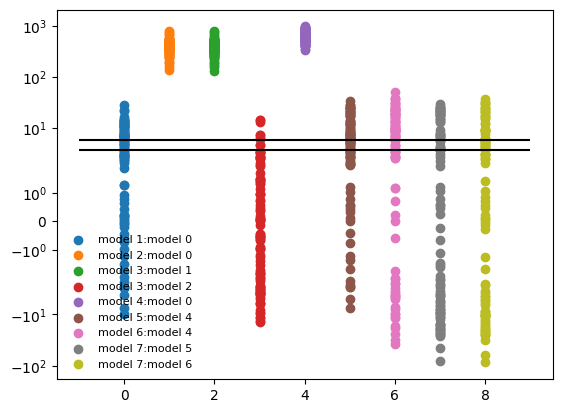

In [8]:
plt.scatter([0] * 100, D_10, label="model 1:model 0")
plt.scatter([1] * 100, D_20, label="model 2:model 0")
plt.scatter([2] * 100, D_31, label="model 3:model 1")
plt.scatter([3] * 100, D_32, label="model 3:model 2")
plt.scatter([4] * 100, D_40, label="model 4:model 0")
plt.scatter([5] * 100, D_54, label="model 5:model 4")
plt.scatter([6] * 100, D_64, label="model 6:model 4")
plt.scatter([7] * 100, D_75, label="model 7:model 5")
plt.scatter([8] * 100, D_76, label="model 7:model 6")
plt.legend(framealpha=0)
plt.hlines([3.8, 6], -1, 9, color="black")
plt.yscale("symlog")

In [9]:
# bootstrap uncerts for model 7

param_file = "models/model_7_params_nobounds.yaml"
pdict = defaultdict(list)

for rep in range(100):
    fname = f"fitted_models/model_7_Bherer_rep_{rep}.yaml"
    pnames, ps = dpluspy.inference._load_params(fname, param_file)
    for pname, p in zip(pnames, ps):
        pdict[pname].append(p)

param_df = pandas.DataFrame(pdict)
param_df.to_csv("model_7_Bherer_bootstrap_mle.csv", index=0)
print(param_df.to_string(index=False))

        T_NDH          T_ND         T_H_N         T_AWN         T_CV        N_Anc          N_H        N_ND       N_Den         N_N       N_Alt     N_Chag       N_Vin   p_S_ND    p_S_D    p_H_N   p_H_WN         m_ND
897208.558118 888123.573684 366654.152482 119963.446592 58843.392182 14119.882597 30551.192466  632.515108 3009.501936 2718.991691  223.228911 133.033151  711.915465 0.000001 0.001262 0.110840 0.013762 6.378084e-06
803037.195265 753594.422134 260404.341204 118540.004570 60181.018958 15147.270413 30054.562672 2225.259059 3270.244145 3031.196002  150.474956 182.198552  891.616095 0.020110 0.008024 0.062955 0.009585 3.200427e-06
748921.038207 685636.603861 162936.893762 119888.302587 59290.697777 15843.447849 28346.365677 4914.661023 2950.685408 2905.120979  242.861343 207.938610  698.141068 0.002850 0.018047 0.011690 0.010169 6.218091e-06
813130.616959 779997.049059 457427.569609 121227.292078 62850.622470 15580.023324 29873.717865 2177.579188 3191.961717 3051.519880  352.6710

In [10]:
for col in param_df.columns:
    print(col, 1.96 * np.std(param_df[col]))

T_NDH 102426.10906335614
T_ND 125167.61001780433
T_H_N 181276.09845906877
T_AWN 8551.959317500072
T_CV 3039.179490348519
N_Anc 1337.2038389410595
N_H 2602.616101696517
N_ND 3199.0856183262154
N_Den 553.3741392576412
N_N 269.4791766495084
N_Alt 651.9031504179782
N_Chag 159.52215401841093
N_Vin 236.80829058634563
p_S_ND 0.020537804979077163
p_S_D 0.010477550514805282
p_H_N 0.07422551795783558
p_H_WN 0.005200854707602639
m_ND 3.6783767988826504e-06


In [11]:
# models
graph0 = "../mass_fit_2/fitted_models/model_0_fit_3.yaml"
graph1 = "../mass_fit_2/fitted_models/model_1_fit_3.yaml"
graph2 = "../mass_fit_2/fitted_models/model_2_fit_24.yaml"
graph4 = "../mass_fit_2/fitted_models/model_4_fit_22.yaml"
graph5 = "../mass_fit_2/fitted_models/model_5_fit_23.yaml"
graph6 = "../mass_fit_2/fitted_models/model_6_fit_6.yaml"

data_file = "../../../analyses/recombination_maps/stats/subset_Bherer.pkl"
u = 1.3e-8

data = dpluspy.inference.load_bootstrap_reps(
    data_file, graph=graph0, return_dict=True)

model0 = dpluspy.inference.compute_bin_stats(graph0, 
    sampled_demes=data["pop_ids"], bins=data["bins"], u=u)
model1 = dpluspy.inference.compute_bin_stats(graph1, 
    sampled_demes=data["pop_ids"], bins=data["bins"], u=u)
model2 = dpluspy.inference.compute_bin_stats(graph2, 
    sampled_demes=data["pop_ids"], bins=data["bins"], u=u)
model4 = dpluspy.inference.compute_bin_stats(graph4, 
    sampled_demes=data["pop_ids"], bins=data["bins"], u=u)
model5 = dpluspy.inference.compute_bin_stats(graph5, 
    sampled_demes=data["pop_ids"], bins=data["bins"], u=u)
model6 = dpluspy.inference.compute_bin_stats(graph6, 
    sampled_demes=data["pop_ids"], bins=data["bins"], u=u)

In [12]:
def plot_on_ax(ax, data, models, stat, title, labels, colors):
    means = data["means"]
    v = data["varcovs"]
    bins = data["bins"]
    x = (bins[1:] + bins[:-1]) / 2
    pop_ids = data["pop_ids"]
    statistics = models[0].names()[0]
    k = statistics.index(stat)

    j = 0
    label = labels[j]
    err = np.array([v[l][k, k] ** 0.5 * 1.96 for l in range(len(x))])
    y = np.array([means[j][k] for j in range(len(x))])
    ax.fill_between(x, y - err, y + err, alpha=0.3, color=colors[j],
                    edgecolor='none')
    ax.plot(x, y, linestyle="dashed", color=colors[j], label=label)
    j += 1
    for model in models:
        label = labels[j]
        y = [model[l][k] for l in range(len(x))]
        ax.plot(x, y, color=colors[j], label=label)
        j += 1
    # ax setup
    ax.set_xscale("log")
    ax.set_title(title, y=0.80, fontsize=7)
    #ax.set_xlabel("$r$")
    #ax.set_xlabel("$D^+$")

In [13]:
print(model2.names())
print(model2.pop_ids)
stats = model2.names()[0]
pop_ids = model2.pop_ids
stats_to_plot = [
    "D+_Vindija_Vindija",
    "D+_Vindija_Denisova",
    "D+_Vindija_Yoruba1",
    "D+_Altai_Yoruba1",
]
_stats_to_plot = []
for stat in stats_to_plot:
    pop0, pop1 = stat.split("_")[1:]
    _stats_to_plot.append(f"D+_{pop_ids.index(pop0)}_{pop_ids.index(pop1)}")
print(_stats_to_plot)
idxs_to_plot = [stats.index(stat) for stat in _stats_to_plot]
print(idxs_to_plot)

(['D+_0_0', 'D+_0_1', 'D+_0_2', 'D+_0_3', 'D+_0_4', 'D+_1_1', 'D+_1_2', 'D+_1_3', 'D+_1_4', 'D+_2_2', 'D+_2_3', 'D+_2_4', 'D+_3_3', 'D+_3_4', 'D+_4_4'], ['H_0_0', 'H_0_1', 'H_0_2', 'H_0_3', 'H_0_4', 'H_1_1', 'H_1_2', 'H_1_3', 'H_1_4', 'H_2_2', 'H_2_3', 'H_2_4', 'H_3_3', 'H_3_4', 'H_4_4'])
['Altai', 'Vindija', 'Chagyrskaya', 'Denisova', 'Yoruba1']
['D+_1_1', 'D+_1_3', 'D+_1_4', 'D+_0_4']
[5, 7, 8, 4]


<>:74: DeprecationWarning: invalid escape sequence '\D'


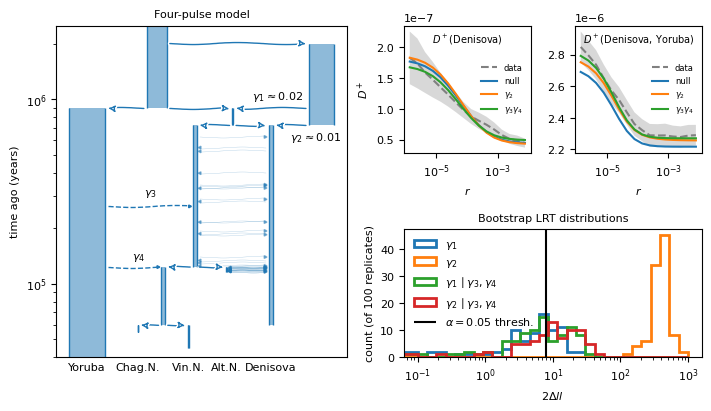

In [14]:
matplotlib.rc("font", size=8)
matplotlib.rc("xtick", labelsize=8)
matplotlib.rc("ytick", labelsize=8)
matplotlib.rc("axes", labelsize=8)
matplotlib.rc("axes", titlesize=8)
matplotlib.rc("legend", fontsize=8)

mosaic = """
ABC
ADD
"""

fig, axs = plt.subplot_mosaic(mosaic, figsize=(7, 4), layout="constrained",
    width_ratios=[2.3, 1, 1])

#for label, ax in axs.items():
#    ax.set_title(label, loc='left', fontsize='medium')

# graph figure
ax = axs["A"]
positions = {
    "Yoruba1": 0,
    "Anc": 55000,
    "Sup": 185000,
    "ND": 115000,
    "WN": 60000,
    "Chagyrskaya": 40000,
    "Vindija": 80000,
    "N": 85000,
    "Altai": 110000,
    "Denisova": 145000,
}
graph = demes.load("edited_models/model_7_fit_0_edited.yaml")
demesdraw.tubes(
    graph,
    ax=ax,
    max_time=2.5e6,
    log_time=True,
    labels=None,
    colours="tab:blue",
    positions=positions
)
samples = ["Yoruba1", "Vindija", "Chagyrskaya", "Altai", "Denisova"]
labels = ["Yoruba", "Vin.N.", "Chag.N.", "Alt.N.", "Denisova"]
xlocs = [positions[sample] for sample in samples]
ax.set_xticks(xlocs, labels)
ax.set_yticks([1e5, 1e6], [r"$10^5$", "$10^6$"])
ax.set_ylim(4e4,)
ax.spines["top"].set_visible(True)
ax.spines["right"].set_visible(True)
ax.spines["bottom"].set_visible(True)

ax.annotate(r"$\gamma_1 \approx 0.02$", (130000, 1e6))
ax.annotate(r"$\gamma_2 \approx 0.01$", (160000, 6e5))
ax.annotate(r"$\gamma_3$", (45000, 3e5))
ax.annotate(r"$\gamma_4$", (35000, 1.35e5))

ax.set_title("Four-pulse model")


bins = np.concatenate([[0], np.logspace(-1, 3, 30)])
axs["D"].hist(D_10, bins=bins, fill=False, edgecolor="tab:blue", linewidth=2, 
    histtype="step", label=r"$\gamma_1$")
axs["D"].hist(D_20, bins=bins, fill=False, edgecolor="tab:orange", linewidth=2, 
    histtype="step", label=r"$\gamma_2$")
axs["D"].hist(D_54, bins=bins, fill=False, edgecolor="tab:green", linewidth=2, 
    histtype="step", label=r"$\gamma_1 \mid \gamma_3, \gamma_4$")
axs["D"].hist(D_64, bins=bins, fill=False, edgecolor="tab:red", linewidth=2, 
    histtype="step", label=r"$\gamma_2 \mid \gamma_3, \gamma_4$")
axs["D"].set_xscale("log")
axs["D"].vlines(scipy.stats.chi2.ppf(0.95, 3), 0, 1, color="black",
    transform=axs["D"].get_xaxis_transform(), label=r"$\alpha = 0.05$ thresh.")
axs["D"].set_ylabel("count (of 100 replicates)")
axs["D"].set_xlabel("$2\Delta ll$")
axs["D"].legend(framealpha=0)
axs["D"].set_title("Bootstrap LRT distributions")


plot_on_ax(axs["B"], data, [model0, model2, model4], "D+_3_3",
    r"$D^+(\text{Denisova})$", 
    ["data", "null", r"$\gamma_2$",  r"$\gamma_3 \gamma_4$"],
    ["grey", "tab:blue", "tab:orange", "tab:green"])
axs["B"].legend(framealpha=0, fontsize=6, loc="center right")

plot_on_ax(axs["C"], data, [model0, model2, model4], "D+_3_4",
    r"$D^+(\text{Denisova, Yoruba})$", 
    ["data", "null", r"$\gamma_2$",  r"$\gamma_3 \gamma_4$"],
    ["grey", "tab:blue", "tab:orange", "tab:green"])
axs["C"].legend(framealpha=0, fontsize=6, loc="center right")





#axs["B"].set_ylim(0.5e-8,)

axs["B"].set_ylabel("$D^+$")

axs["B"].set_xlabel("$r$")
axs["C"].set_xlabel("$r$")

plt.savefig("figures/big_figure.svg", transparent=True)


In [15]:
def plot_on_ax(ax, data, model, stats, labels, colors, title):
    means = data["means"]
    v = data["varcovs"]
    bins = data["bins"]
    x = (bins[1:] + bins[:-1]) / 2
    pop_ids = data["pop_ids"]
    statistics = model.names()[0]

    for j, stat in enumerate(stats):
        k = statistics.index(stat)
        label = labels[j]
        err = np.array([v[l][k, k] ** 0.5 * 1.96 for l in range(len(x))])
        y = np.array([means[j][k] for j in range(len(x))])
        ax.fill_between(x, y - err, y + err, alpha=0.3, color=colors[j],
                        edgecolor='none')
        ax.plot(x, y, linestyle="dashed", color=colors[j])
        y = [model[l][k] for l in range(len(x))]
        ax.plot(x, y, color=colors[j], label=label)
    # ax setup
    # logfmt = matplotlib.ticker.LogFormatterExponent(base=10.0, labelOnlyBase=True)
    # ax.yaxis.set_major_formatter(logfmt)
    ax.set_xscale("log")
    ax.set_title(title, fontsize=7,)
    #ax.set_xlabel("$r$")
    #ax.set_xlabel("$D^+$")


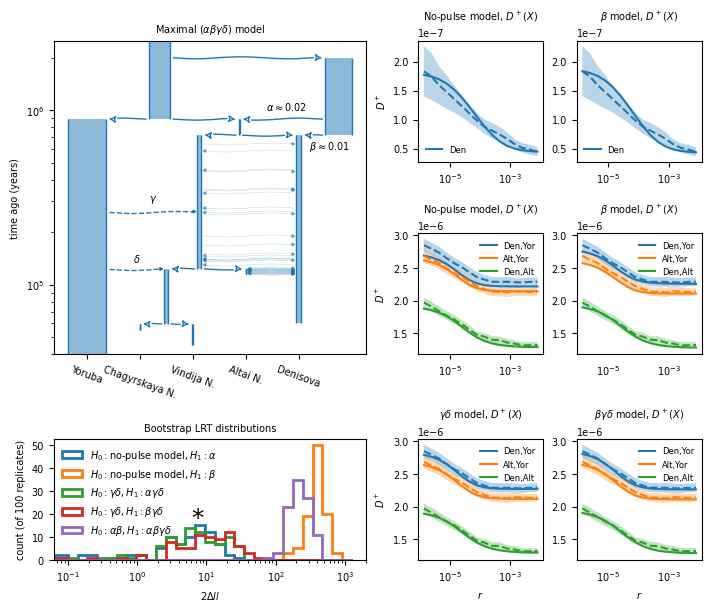

In [21]:
matplotlib.rc("font", size=7)
matplotlib.rc("xtick", labelsize=7)
matplotlib.rc("ytick", labelsize=7)
matplotlib.rc("axes", labelsize=7)
matplotlib.rc("axes", titlesize=7)
matplotlib.rc("legend", fontsize=7)

mosaic = """
ABC
ADE
FGH
"""
fig, axs = plt.subplot_mosaic(mosaic, figsize=(7, 6), layout="constrained",
    width_ratios=[2.5, 1, 1])


graph = demes.load("edited_models/model_7_fit_0_edited.yaml")
positions = {
    "Yoruba1": 0,
    "Anc": 55000,
    "Sup": 190000,
    "ND": 115000,
    "WN": 60000,
    "Chagyrskaya": 40000,
    "Vindija": 80000,
    "N": 85000,
    "Altai": 120000,
    "Denisova": 160000,
}
samples = ["Yoruba1", "Vindija", "Chagyrskaya", "Altai", "Denisova"]
labels = ["Yoruba", "Vindija N.", "Chagyrskaya N.", "Altai N.", "Denisova"]

axs["A"].set_title(r"Maximal ($\alpha \beta \gamma \delta$) model")
demesdraw.tubes(
    graph,
    ax=axs["A"],
    max_time=2.5e6,
    log_time=True,
    labels=None,
    colours="tab:blue",
    positions=positions
)
axs["A"].spines["top"].set_visible(True)
axs["A"].spines["right"].set_visible(True)
axs["A"].spines["bottom"].set_visible(True)
xlocs = [positions[sample] for sample in samples]
axs["A"].tick_params(axis="x", reset=True, bottom=True, top=False)
axs["A"].set_xticks(xlocs, labels, rotation=-20)
axs["A"].set_ylim(4e4, )

axs["A"].annotate(r"$\alpha \approx 0.02$", (135000, 1e6))
axs["A"].annotate(r"$\beta \approx 0.01$", (168000, 6e5))
axs["A"].annotate(r"$\gamma$", (47000, 3e5))
axs["A"].annotate(r"$\delta$", (35000, 1.35e5))


bins = np.concatenate([[0], np.logspace(-1, 3.1, 30)])
axs["F"].hist(D_10, bins=bins, fill=False, edgecolor="tab:blue", linewidth=2, 
    histtype="step", label=r"$H_0: \text{no-pulse model}, H_1: \alpha$")
axs["F"].hist(D_20, bins=bins, fill=False, edgecolor="tab:orange", linewidth=2, 
    histtype="step", label=r"$H_0: \text{no-pulse model}, H_1: \beta$")
axs["F"].hist(D_54, bins=bins, fill=False, edgecolor="tab:green", linewidth=2, 
    histtype="step", label=r"$H_0: \gamma \delta, H_1: \alpha \gamma \delta$")
axs["F"].hist(D_64, bins=bins, fill=False, edgecolor="tab:red", linewidth=2, 
    histtype="step", label=r"$H_0: \gamma \delta, H_1: \beta \gamma \delta$")
axs["F"].hist(D_73, bins=bins, fill=False, edgecolor="tab:purple", linewidth=2, 
    histtype="step", label=r"$H_0: \alpha \beta, H_1: \alpha \beta \gamma \delta$")

axs["F"].set_xscale("log")
axs["F"].annotate("*", (scipy.stats.chi2.ppf(0.95, 2), 15), color="black",
    fontsize=18)
axs["F"].set_ylabel("count (of 100 replicates)")
axs["F"].set_xlabel(r"$2\Delta ll$")
axs["F"].legend(framealpha=0)
axs["F"].set_title("Bootstrap LRT distributions")



plot_on_ax(
    axs["B"], 
    data, 
    model0, 
    ["D+_3_3"],
    ["Den"],
    ["tab:blue", "tab:orange"],
    r"No-pulse model, $D^+(X)$"
)
axs["B"].legend(framealpha=0, fontsize=6, loc="lower left")
plot_on_ax(
    axs["C"], 
    data, 
    model2, 
    ["D+_3_3"],
    ["Den"],
    ["tab:blue", "tab:orange"],
    r"$\beta$ model, $D^+(X)$"
)
axs["C"].legend(framealpha=0, fontsize=6, loc="lower left")
axs["B"].sharey(axs["C"])


plot_on_ax(
    axs["D"], 
    data, 
    model0, 
    ["D+_3_4", "D+_0_4", "D+_0_3"],
    ["Den,Yor", "Alt,Yor", "Den,Alt"],
    ["tab:blue", "tab:orange", "tab:green"],
    r"No-pulse model, $D^+(X)$"
)
axs["D"].legend(framealpha=0, fontsize=6, loc="upper right")
plot_on_ax(
    axs["E"], 
    data, 
    model2, 
    ["D+_3_4", "D+_0_4", "D+_0_3"],
    ["Den,Yor", "Alt,Yor", "Den,Alt"],
    ["tab:blue", "tab:orange", "tab:green"],
    r"$\beta$ model, $D^+(X)$"
)
axs["E"].legend(framealpha=0, fontsize=6, loc="upper right")
axs["E"].sharey(axs["D"])
axs["E"].tick_params(axis="x", bottom=False)



plot_on_ax(
    axs["G"], 
    data, 
    model4, 
    ["D+_3_4", "D+_0_4", "D+_0_3"],
    ["Den,Yor", "Alt,Yor", "Den,Alt"],
    ["tab:blue", "tab:orange", "tab:green"],
    r"$\gamma \delta$ model, $D^+(X)$"
)
axs["G"].legend(framealpha=0, fontsize=6, loc="upper right")
plot_on_ax(
    axs["H"], 
    data, 
    model6, 
    ["D+_3_4", "D+_0_4", "D+_0_3"],
    ["Den,Yor", "Alt,Yor", "Den,Alt"],
    ["tab:blue", "tab:orange", "tab:green"],
    r"$\beta \gamma \delta$ model, $D^+(X)$"
)
axs["H"].legend(framealpha=0, fontsize=6, loc="upper right")
axs["H"].sharey(axs["G"])
axs["H"].tick_params(axis="x", bottom=False)



# labels
axs["B"].set_ylabel("$D^+$")
axs["D"].set_ylabel("$D^+$")
axs["G"].set_ylabel("$D^+$")

axs["H"].set_xlabel("$r$")
axs["B"].sharex(axs["G"])
axs["D"].sharex(axs["G"])
axs["G"].set_xlabel("$r$")
axs["C"].sharex(axs["H"])
axs["E"].sharex(axs["H"])


plt.savefig("figures/bigger_figure.svg", transparent=True)
